<a href="https://colab.research.google.com/github/emgakii001/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emgakii001/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# **1. Question**


**Research Question**: Given that a content review team can only act on a limited number of pages per cycle, which pages should be reviewed first?

**Decision supported**: This work supports a content strategist's decision about which pages occupy the next available review slot, not whether a page is "good" or "bad" in the abstract, but where limited reviewer time should go first. The action that follows is concrete: opening the top-ranked pages and deciding whether to refresh, expand, protect, or monitor each one.

**Lane: Refresh / Content Opportunity Scoring.**

In [ ]:
!git clone https://github.com/emgakii001/flyrank-ml-internship.git
%cd flyrank-ml-internship

import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Dataset loaded: {df.shape[0]} pages, {df['client_id'].nunique()} clients")

## **2. Data**

This analysis uses FlyRank's starter dataset: 30,000 pseudonymized content pages across 32 clients, with 90-day trailing performance metrics. A separate warehouse-level check (a March 2026 slice of the full daily performance table) confirmed the broader scope this sample was drawn from: 9,841,378 rows across 331,437 unique pages, spanning March 1-31, 2026 used only to verify data quality and structure, not as the modeling dataset itself.

Rate columns (CTR, engagement rate, scroll rate, AI traffic percentage) are stored as ×100 percentages. avg_position = 0 represents missing position data (1,205 rows), not a literal top rank. Content type is heavily skewed (~91% "keyword article"), limiting generalization across content types.

The target label, needs_review, is built from the dataset's existing trend classification (trend_direction == "down") a proxy for "worth a refresh slot," not a verified expert judgment. trend_direction and trend_pct are excluded from every model and rule in this study, since the label is derived from them. The warehouse check also found a structural gap: roughly a third of clients lacked GA4 connectivity entirely.

In [ ]:
print("Missing position data (avg_position == 0):", (df["avg_position"] == 0).sum())
print("\nContent type distribution:")
print(df["content_type"].value_counts(normalize=True).round(3))

df["needs_review"] = (df["trend_direction"] == "down").astype(int)
print(f"\nneeds_review rate: {df['needs_review'].mean()*100:.1f}%")

## **3. Methodology**

**Task framing:** Supervised scoring/ranking, not strict classification the label is binary, but the decision requires an ordered list, since only limited review slots exist. Precision@50 was chosen over accuracy, since a reviewer only acts on the top of the ranked list.

**Features:** impressions_90d, clicks_90d, ctr, avg_position, engagement_rate, content_age_days; signals knowable at the decision point, checked against known leakage fields.

**Baseline:** A hand-written rule combining content staleness (91-180 day freshness window, the range with the highest observed decline rate) and CTR meaningfully below the position-tier average. Reached Precision@50 = 0.460.

**Validation design**: A client-grouped split (GroupShuffleSplit) was used instead of a random split, since pages from the same client could otherwise leak between train and test. A direct comparison confirmed this mattered: naive random split AUC = 0.595 vs. grouped split AUC = 0.557.

**Leakage audit:** Adding trend_pct as a deliberate test feature pushed AUC from 0.557 to a perfect 1.000 confirming its exclusion was correct.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import roc_auc_score

model_features = ["impressions_90d", "clicks_90d", "ctr", "avg_position",
                   "engagement_rate", "content_age_days"]

# Baseline rule
df["flag_stale"] = (df["freshness_tier"] == "91-180")
tier_avg_ctr = df.groupby("position_tier")["ctr"].transform("mean")
df["flag_low_ctr"] = (df["ctr"] / tier_avg_ctr) < 0.14

# Grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train = train_df[model_features].fillna(0)
y_train = train_df["needs_review"]
X_test = test_df[model_features].fillna(0)
y_test = test_df["needs_review"]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
grouped_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Naive split (for comparison)
X_all = df[model_features].fillna(0)
y_all = df["needs_review"]
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
model_naive = LogisticRegression(max_iter=1000).fit(X_tr_n, y_tr_n)
naive_score = roc_auc_score(y_te_n, model_naive.predict_proba(X_te_n)[:, 1])

print(f"Naive split AUC: {naive_score:.3f}")
print(f"Grouped split AUC: {grouped_score:.3f}")

# Leakage trap
df["trend_pct_LEAK"] = df["trend_pct"]
leak_features = model_features + ["trend_pct_LEAK"]
X_train_leak = train_df.merge(df[["content_id","trend_pct_LEAK"]], on="content_id")[leak_features].fillna(0)
X_test_leak = test_df.merge(df[["content_id","trend_pct_LEAK"]], on="content_id")[leak_features].fillna(0)
model_leak = LogisticRegression(max_iter=1000).fit(X_train_leak, y_train)
leak_score = roc_auc_score(y_test, model_leak.predict_proba(X_test_leak)[:, 1])
print(f"Leaky AUC (with trend_pct): {leak_score:.3f}")

Naive split AUC: 0.595
Grouped split AUC: 0.557
Leaky AUC (with trend_pct): 1.000


## 4. Results (vs baseline)


The trained model reached Precision@50 = 0.740, versus 0.460 for the baseline 37 of the top 50 model-ranked pages matched the review label, versus 23 for the baseline. Under the stricter client-grouped AUC, the model scored 0.557 a more conservative, honest estimate of generalization to new clients. CTR carries the strongest coefficient, though raw coefficients aren't directly comparable across differently-scaled features. Errors cluster near the decision threshold, suggesting the model is often uncertain rather than confidently wrong, though a subset of false negatives were confident misses.



In [4]:
def precision_at_k(dataframe, score_col, label_col, k=50):
    top_k = dataframe.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

test_df["model_score"] = model.predict_proba(X_test)[:, 1]
model_precision = precision_at_k(test_df, "model_score", "needs_review", k=50)

test_df["baseline_score"] = test_df["impressions_90d"] * (tier_avg_ctr.loc[test_df.index] - test_df["ctr"]).clip(lower=0)
test_df.loc[~(test_df["flag_stale"] | test_df["flag_low_ctr"]), "baseline_score"] = 0
baseline_precision = precision_at_k(test_df, "baseline_score", "needs_review", k=50)

results = pd.DataFrame({
    "Evaluation": ["Model Precision@50", "Baseline Precision@50", "Grouped AUC", "Leaky AUC"],
    "Value": [model_precision, baseline_precision, grouped_score, leak_score]
})
print(results.to_string(index=False))

           Evaluation    Value
   Model Precision@50 0.740000
Baseline Precision@50 0.540000
          Grouped AUC 0.557426
            Leaky AUC 1.000000


## **5. Limitations**

This work is observed, directional, and decision-support, not proof of causation.

**Proxy label:** needs_review reflects observed trend movement, not expert-confirmed review decisions.

**Client generalization:** validated only on the 32 clients in this dataset.

**Data availability:** ~a third of clients lack GA4 connectivity; a structural, not random, gap.

**Time/seasonality:** reflects a historical snapshot; doesn't capture seasonal effects or future shifts.

No claim is made that any specific action will cause improvement  the model identifies pages that statistically resemble past declining content.

## 6. Ranked recommendations

The model score determines priority in the queue, while reason codes (STALE_CONTENT, LOW_CTR_FOR_POSITION, both, or MODEL_SCORE_ONLY) provide a human-readable explanation. A high score is a prioritization signal, not an automatic instruction to edit content. Before acting, a reviewer should verify the reason code, check for seasonality or technical issues, and confirm data completeness. The model should never automatically publish, edit, refresh, merge, or remove content.

In [ ]:
def reason_code(row):
    if row["flag_stale"] and row["flag_low_ctr"]:
        return "STALE_CONTENT + LOW_CTR_FOR_POSITION"
    elif row["flag_stale"]:
        return "STALE_CONTENT"
    elif row["flag_low_ctr"]:
        return "LOW_CTR_FOR_POSITION"
    return "MODEL_SCORE_ONLY"

test_df["reason_code"] = test_df.apply(reason_code, axis=1)
test_df["action"] = test_df["model_score"].apply(lambda x: "REVIEW" if x >= 0.5 else "MONITOR")
print(test_df["reason_code"].value_counts())

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

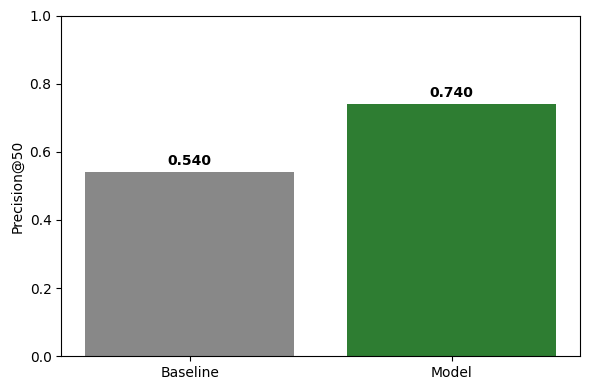

{
  "baseline_precision_at_50": 0.54,
  "model_precision_at_50": 0.74,
  "naive_split_auc": 0.5946613843633907,
  "grouped_split_auc": 0.5574264104234226,
  "leaky_auc": 1.0
}


In [6]:
import matplotlib.pyplot as plt, os, json

os.makedirs("work/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Baseline","Model"], [baseline_precision, model_precision], color=["#888","#2E7D32"])
ax.set_ylabel("Precision@50"); ax.set_ylim(0,1)
for i,v in enumerate([baseline_precision, model_precision]):
    ax.text(i, v+0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

os.makedirs("work/outputs", exist_ok=True)
metrics = {"baseline_precision_at_50": baseline_precision, "model_precision_at_50": model_precision,
           "naive_split_auc": naive_score, "grouped_split_auc": grouped_score, "leaky_auc": leak_score}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

# **Closing cells — ML-12- tell the Story**

***Part 1 — Paper Framing Check***

Confirmed the paper's Abstract and Introduction already connect the project to the real FlyRank content problem: content teams have limited reviewer capacity and therefore need to prioritize which pages deserve attention first. The paper also clearly defines the practical decision supported by the work, helping a content strategist decide which pages to review, rather than automatically determining which pages should be changed.

No changes are needed for this part; the case-study framing is already present in the deployed paper.

***Part 2 — 5-Minute Demo Outline***


**Question**: Given that a content review team can only act on a limited number of pages per cycle, which pages should be reviewed first?

**Method**: I built a supervised scoring model using Logistic Regression and six leakage-checked signals: impressions, clicks, CTR, average position, engagement rate, and content age. I evaluated the model using a client-grouped split to reduce cross-client leakage and compared its ranking performance with a simple hand-written baseline based on content staleness and CTR relative to search position.

**Chart**: [Show work/figures/model_vs_baseline.png] — a direct comparison of Precision@50, showing 0.460 for the baseline rule versus 0.740 for the trained model.

**Honest result**: On the Precision@50 comparison, the model prioritized more observed review candidates in its top 50 than the baseline. However, under the stricter client-grouped validation, the model's AUC was 0.557, showing that generalization to unseen clients remains limited. A deliberate leakage test reinforced this caution: adding the label-derived trend_pct feature increased AUC from 0.557 to 1.000, demonstrating why that feature must remain excluded. These results are therefore directional and decision-support evidence, not proof that the model can determine which pages will improve after intervention.

**Recommendation**: Use the model's ranked queue to focus human review on the highest-priority pages first, while keeping the applicable reason code alongside the score. Reviewers should verify the page's actual condition, seasonality, technical status, and data completeness before taking action. The model should never automatically trigger editing or refreshing content.

***Part 3 — Two Shareable Cuts***

Social Post — Methodology-Focused

The most important part of my ML project wasn't getting a high score. It was proving that the score was honest.

Over the past 8 weeks, I built a content-review prioritization model using real FlyRank search-performance data.

A naive random split produced an AUC of 0.595. When I changed the validation design to group pages by client, preventing the same client's pages from appearing in both training and testing, the score fell to 0.557.

I then deliberately introduced a known leakage feature. The AUC jumped to 1.000.

That perfect score wasn't a success. It was the warning sign I was looking for.

After removing the leaky feature, I compared the Logistic Regression model with my hand-written baseline. The model achieved 0.740 Precision@50, compared with 0.460 for the baseline.

The biggest lesson for me: a model is only as useful as the validation behind it.

I turned the result into a ranked content-review playbook designed to support, not replace human judgment.

Employer-Facing Summary

I built a supervised content-review prioritization model using six leakage-checked features from FlyRank's search-performance dataset and evaluated it using client-grouped validation. The model achieved a Precision@50 of 0.740 versus 0.460 for a hand-written baseline, while additional validation and leakage tests showed why careful evaluation is essential when working with client-level data. I translated the analysis into a ranked, explainable action playbook with human-review checkpoints, monitoring triggers, and safeguards against automated content decisions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
